In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load the Dataset and name the target 'HousePrice'
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Step 2: Separate input features (X) from the answer target (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Step 3: Feature Scaling (Puts all numbers on a common scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Step 5: Setup the 3 different AI models to test
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

# Step 6: Train and score each model automatically
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Calculate errors and accuracy scores
    rmse = mean_squared_error(y_test, predictions, squared=False)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Step 7: Display the comparative Scoreboard Table
results_df = pd.DataFrame(results).T
print("--- FINAL PERFORMANCE SCOREBOARD ---")
print(results_df)
print("\n------------------------------------")

# Step 8: Plot the chart for the best model (Decision Tree)
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="purple")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree Winner)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.show()

TypeError: got an unexpected keyword argument 'squared'

--- FINAL PERFORMANCE SCOREBOARD ---
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732

------------------------------------


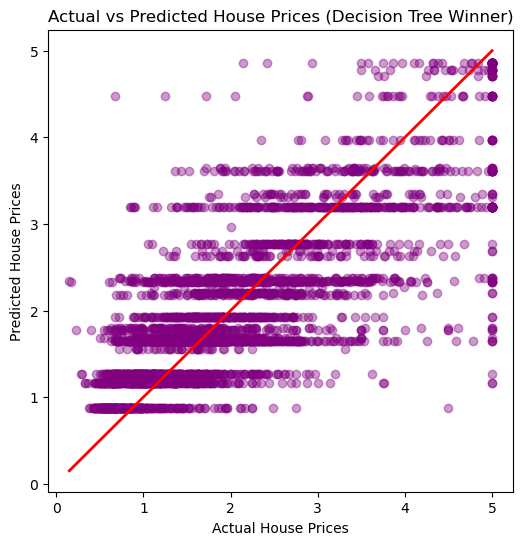

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load the Dataset and name the target 'HousePrice'[cite: 2]
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Step 2: Separate input features (X) from the answer target (y)[cite: 2]
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Step 3: Feature Scaling (Puts all numbers on a common scale)[cite: 2]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split data into 80% training and 20% testing[cite: 2]
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Step 5: Setup the 3 different AI models to test[cite: 2]
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

# Step 6: Train and score each model automatically[cite: 2]
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # FIX: Using np.sqrt() instead of the deprecated squared=False argument[cite: 2]
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Step 7: Display the comparative Scoreboard Table[cite: 2]
results_df = pd.DataFrame(results).T
print("--- FINAL PERFORMANCE SCOREBOARD ---")
print(results_df)
print("\n------------------------------------")

# Step 8: Plot the chart for the best model (Decision Tree)[cite: 2]
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="purple")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree Winner)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.show()